In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
np.set_printoptions(suppress=True)

import json

with open('../config.json', 'r') as f:
    config = json.load(f)

ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']
NORMALISATION_TO_FE = config["normalisation_to_Fe"]

PREDICTION_PATH_DICT = config["prediction_path"]
PREDICTION_INPUT_PATH_DICT = config["prediction_input_path"]
FIGURES_PATH = config["figures_path"]['all']

DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik', 'artificial_inks']

CMAP = plt.get_cmap('tab20')

In [2]:
df, y_true = join_datasets_into_one(
                            DATASETS, 
                            PREDICTION_PATH_DICT,
                            PREDICTION_INPUT_PATH_DICT,
                            ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP
                            )

X = np.array(df.values)

In [3]:
#version with normalisation to Fe
# X = X/(X[:,7].reshape(-1,1))
# X = np.concatenate([X[:,:7], X[:,8:]], axis=1)

In [4]:
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [9]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.components_

array([[-0.10611023,  0.23937109,  0.42599201,  0.44763064,  0.06553004,
         0.61784244, -0.21429991,  0.02202231,  0.19701547,  0.14216027,
         0.24112692],
       [ 0.03659067,  0.06089284, -0.03610019,  0.14523929,  0.4807244 ,
        -0.092273  ,  0.67963986,  0.42660792,  0.15128952,  0.15234954,
         0.20722375],
       [-0.22570847, -0.07710943, -0.07694809, -0.0632173 ,  0.81978433,
        -0.05423515, -0.4571901 , -0.02559565, -0.04003112, -0.18220387,
        -0.11715768]])

In [6]:
pca.components_[0,:] #PC1

array([-0.10611023,  0.23937109,  0.42599201,  0.44763064,  0.06553004,
        0.61784244, -0.21429991,  0.02202231,  0.19701547,  0.14216027,
        0.24112692])

In [7]:
pca.components_[1,:] #PC2

array([ 0.03659067,  0.06089284, -0.03610019,  0.14523929,  0.4807244 ,
       -0.092273  ,  0.67963986,  0.42660792,  0.15128952,  0.15234954,
        0.20722375])

In [8]:
pca.components_[2,:] #PC3

array([-0.22570847, -0.07710943, -0.07694809, -0.0632173 ,  0.81978433,
       -0.05423515, -0.4571901 , -0.02559565, -0.04003112, -0.18220387,
       -0.11715768])

In [9]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.explained_variance_ratio_

array([0.48893283, 0.15520324, 0.11075563])

In [10]:
# elements corresponding to consecutive dimensions
print(ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP)

['Al', 'S', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Fe', 'Mg', 'Na', 'K']


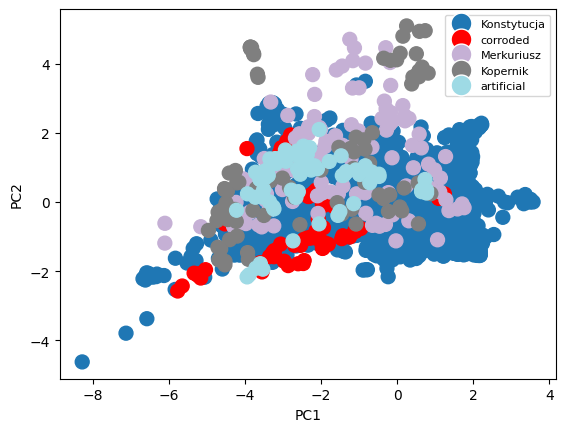

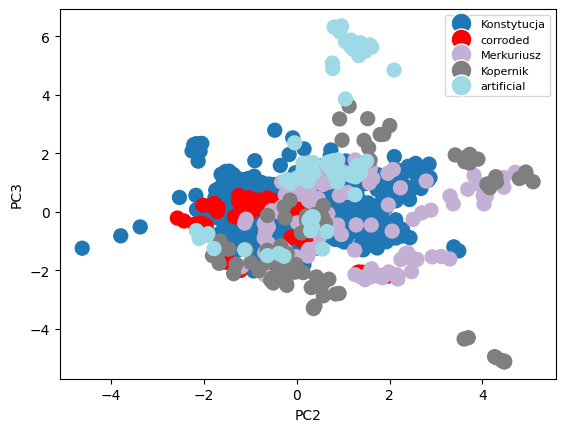

In [11]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=None)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

In [15]:
DATASET = "Konstytucja"

ELEMENTS_TO_KEEP = config["elements_to_keep"]
NORMALISATION_TO_FE = config["normalisation_to_Fe"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']

PREDICTION_PATH = config["prediction_path"][DATASET]
PREDICTION_INPUT_PATH = config["prediction_input_path"][DATASET]
FIGURES_PATH = config["figures_path"][DATASET]

if DATASET == "Konstytucja":
    CMAP = plt.get_cmap('hsv')
else:
    CMAP = plt.get_cmap('tab20')


# ## Loading the data

df = load_prediction(PREDICTION_PATH, ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP)
inds_df = load_target_data(PREDICTION_INPUT_PATH)
y_true = create_sample_id_in_target_data(inds_df, column_to_use='name')['Sample_id']

# ### Converting to np.array

X = np.array(df.values)

# PCA
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [16]:
# # ### Heatmap - datasets separately

# visualise_clustering_on_heatmap(X, y_true.values, ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP, figures_path=FIGURES_PATH)

In [17]:
def visualise_pca(X_low_dim, y,
                    dimensions = [0,1],
                    figures_name = 'pca',
                    cmap=plt.get_cmap('tab20'),
                    annotate = False,
                    whether_sort = True,
                    figures_path=None):

    colors = cmap(np.linspace(0, 0.99, y.nunique()))

    if whether_sort:
        sorted_labels = sorted(y.unique())
    else:
        sorted_labels = y.unique()

    color_dict = dict((key, value) for key, value in zip(sorted_labels, colors))
    color_dict['corroded'] = [1., 0., 0., 1.]
    legend_elements = [Line2D([0], [0], color='w', marker='o', markerfacecolor=color_dict[label],
                                                  label=label, markersize=15) for label in sorted_labels]
    
    x_pca_0 = [X_low_dim[i, dimensions[0]] for i in range(X_low_dim.shape[0])]
    x_pca_1 = [X_low_dim[i, dimensions[1]] for i in range(X_low_dim.shape[0])]
    y_colors = np.array([color_dict[el] for el in y])

    plt.xlabel('PC' + str(dimensions[0]+1))
    plt.ylabel('PC' + str(dimensions[1]+1))

    plt.scatter(x_pca_0, x_pca_1, marker='o', s=100, color=y_colors, alpha=0.5)
    plt.legend(handles=legend_elements, prop={'size': 8})
            
    if figures_path is not None:
        plt.savefig(figures_path + '_' + figures_name + '_' + 'PC' + str(dimensions[0]+1) + '_' + 'PC' + str(dimensions[1]+1) + '.png')
    plt.show()

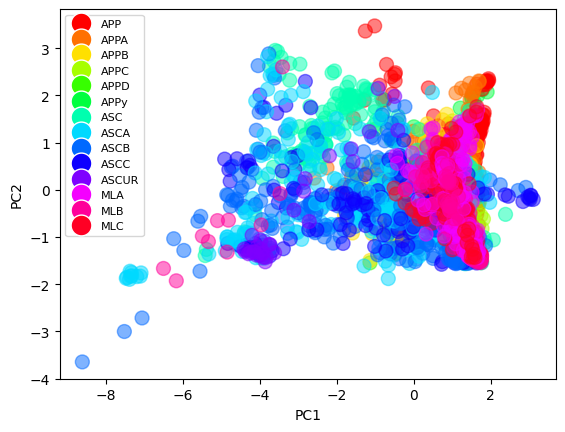

In [18]:
visualise_pca(X_pca, y_true.apply(lambda x: ''.join(l for l in x if l.isalpha())), cmap=CMAP, figures_path=FIGURES_PATH + DATASET)

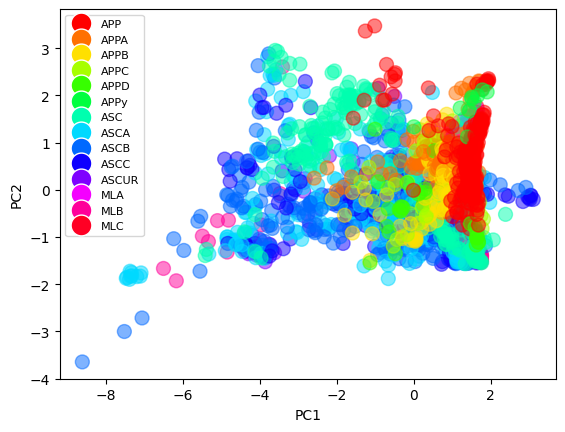

In [19]:
visualise_pca(X_pca[::-1], y_true[::-1].apply(lambda x: ''.join(l for l in x if l.isalpha())), cmap=CMAP, figures_path=FIGURES_PATH + DATASET)

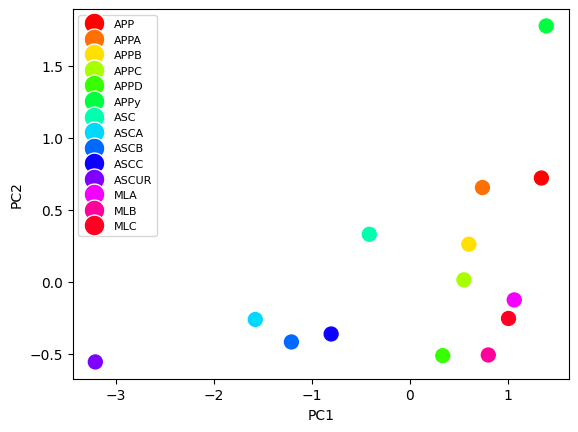

In [20]:
visualise_means_pca(X_pca, y_true.apply(lambda x: ''.join(l for l in x if l.isalpha())), cmap=CMAP, figures_path=FIGURES_PATH + DATASET)
